<div style="background:linear-gradient(135deg,#136a8a 0%,#267871 100%);padding:32px 34px;border-radius:16px;
            box-shadow:0 8px 24px rgba(0,0,0,0.18);font-family:'Segoe UI',Roboto,sans-serif;">
  <h1 style="margin:0;color:#ffffff;font-size:34px;letter-spacing:-0.5px;">🌀&nbsp; 2-D Navier–Stokes: the Taylor–Green Vortex</h1>
  <p style="margin:12px 0 0;color:#eaf6ff;font-size:17px;line-height:1.5;max-width:760px;">We step up to a coupled <i>system</i> of PDEs — incompressible Navier–Stokes — and let a single network predict velocity and pressure. The Taylor–Green vortex gives us an exact solution to check against.</p>
</div>

<div><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">level</span><span style="background:#d6336c;color:#fff;padding:4px 8px;">advanced</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">topic</span><span style="background:#1a73e8;color:#fff;padding:4px 8px;">fluid dynamics · system PDE</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">PDE</span><span style="background:#7b3fe4;color:#fff;padding:4px 8px;">incompressible Navier–Stokes</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">runtime</span><span style="background:#603813;color:#fff;padding:4px 8px;">~2 min · CPU</span></span></div>

The incompressible Navier–Stokes equations describe how a fluid's velocity field
$(u, v)$ and pressure $p$ evolve. A PINN handles the whole coupled system at once: one network with
three outputs, trained on the momentum + continuity residuals.

<div style="background:#f6f8fa;border:1px solid #e1e4e8;border-radius:10px;padding:18px 24px;
            font-family:'Segoe UI',sans-serif;">
  <b style="font-size:15px;">📑 Table of Contents</b>
  <ol style="margin:10px 0 0;padding-left:20px;font-size:14px;line-height:1.6;">
  <li style="margin:3px 0;"><a href="#physics" style="color:#1a73e8;text-decoration:none;">1 · The Equations</a></li>
  <li style="margin:3px 0;"><a href="#tgv" style="color:#1a73e8;text-decoration:none;">2 · The Taylor–Green Vortex</a></li>
  <li style="margin:3px 0;"><a href="#setup" style="color:#1a73e8;text-decoration:none;">3 · Setup</a></li>
  <li style="margin:3px 0;"><a href="#train" style="color:#1a73e8;text-decoration:none;">4 · Training the Solver</a></li>
  <li style="margin:3px 0;"><a href="#fields" style="color:#1a73e8;text-decoration:none;">5 · Predicted Flow Field</a></li>
  <li style="margin:3px 0;"><a href="#accuracy" style="color:#1a73e8;text-decoration:none;">6 · Accuracy vs. the Exact Vortex</a></li>
  <li style="margin:3px 0;"><a href="#takeaways" style="color:#1a73e8;text-decoration:none;">7 · Takeaways</a></li>
  </ol>
</div>

<a id="physics"></a>

## 1 · The Equations

$$\frac{\partial \mathbf{u}}{\partial t} + (\mathbf{u}\cdot\nabla)\mathbf{u}
= -\nabla p + \nu\,\nabla^2 \mathbf{u}, \qquad \nabla\cdot\mathbf{u} = 0,$$

with $\mathbf{u}=(u,v)$. The first equation is **momentum** (Newton's law for a fluid parcel); the
second is **incompressibility** (mass conservation). The network maps $(t,x,y)\mapsto(u,v,p)$.

<a id="tgv"></a>

## 2 · The Taylor–Green Vortex

A classic decaying-vortex solution with a closed form — perfect for validation.

$$u = \sin x \cos y\, e^{-2\nu t}, \quad v = -\cos x \sin y\, e^{-2\nu t}, \quad
p = -\tfrac{1}{4}(\cos 2x + \cos 2y)\, e^{-4\nu t}.$$

The vortices spin and slowly decay under viscosity $\nu$.

<a id="setup"></a>

## 3 · Setup

In [1]:
# --- Environment setup -------------------------------------------------------
import warnings, logging, os
warnings.filterwarnings("ignore")
logging.getLogger("pinnlab").setLevel(logging.ERROR)          # quiet library logs

# Disable tqdm progress bars for clean, static notebook output
from functools import partialmethod
import tqdm
tqdm.tqdm.__init__ = partialmethod(tqdm.tqdm.__init__, disable=True)

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl

# A clean, consistent "Kaggle" plotting theme ---------------------------------
plt.rcParams.update({
    "figure.figsize":   (9, 5),
    "figure.dpi":       110,
    "savefig.dpi":      110,
    "font.size":        11,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "axes.edgecolor":   "#cccccc",
    "axes.grid":        True,
    "grid.color":       "#e6e6e6",
    "grid.linewidth":   0.8,
    "axes.axisbelow":   True,
    "legend.frameon":   True,
    "legend.framealpha":0.9,
})
ACCENT, ACCENT2, ACCENT3 = "#1a73e8", "#d6336c", "#1e9e54"

# Reproducibility -------------------------------------------------------------
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

import pinnlab
print(f"pinnlab      : {pinnlab.__version__}")
print(f"PyTorch      : {torch.__version__}")
print(f"Compute      : {DEVICE.upper()}")

pinnlab      : 0.5.0
PyTorch      : 2.11.0+cpu
Compute      : CPU


<a id="train"></a>

## 4 · Training the Solver

The library ships a ready `NavierStokesPINN`. We train it briefly on CPU — enough to reproduce the vortex structure.

In [2]:
from pinnlab.models import MLP
from pinnlab.solvers.navier_stokes import (
    NSConfig, NavierStokesPINN, TrainConfig, tgv_u, tgv_v)

cfg = NSConfig()
print(f"Domain: x,y in [0, 2π],  t in [{cfg.tmin}, {cfg.tmax}],  ν = {cfg.nu}")

model = MLP(in_dim=3, hidden_layers=5, width=48, out_dim=3)   # (t,x,y) -> (u,v,p)
pinn = NavierStokesPINN(model=model, cfg=cfg, device=DEVICE)

import time; t0 = time.time()
pinn.train(TrainConfig(n_ic=300, n_f=2_500, n_per=400, lr=1e-3, adam_steps=3_000))
print(f"Trained in {time.time()-t0:.0f} s")

Domain: x,y in [0, 2π],  t in [0.0, 1.0],  ν = 0.01


Trained in 591 s


<a id="fields"></a>

## 5 · Predicted Flow Field

We evaluate the network on a snapshot at t = 0.5 and visualise speed and velocity vectors.

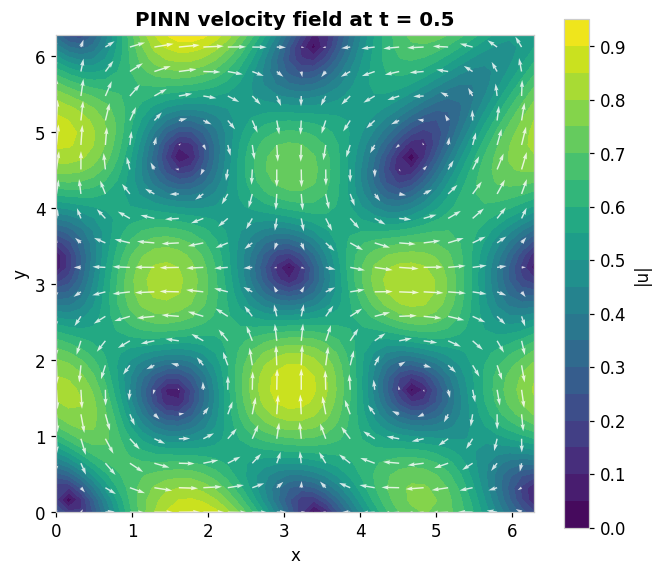

In [3]:
t_snap = 0.5
g = np.linspace(cfg.xmin, cfg.xmax, 40, dtype=np.float32)
X, Y = np.meshgrid(g, g, indexing="xy")
T = np.full_like(X, t_snap)
with torch.no_grad():
    inp = torch.tensor(np.stack([T.ravel(), X.ravel(), Y.ravel()], 1),
                       dtype=torch.float32, device=DEVICE)
    out = model(inp).cpu().numpy()
U = out[:, 0].reshape(X.shape); V = out[:, 1].reshape(X.shape)
speed = np.sqrt(U**2 + V**2)

fig, ax = plt.subplots(figsize=(7, 6))
cf = ax.contourf(X, Y, speed, levels=20, cmap="viridis")
ax.quiver(X[::2, ::2], Y[::2, ::2], U[::2, ::2], V[::2, ::2], color="white", alpha=0.8)
ax.set(title=f"PINN velocity field at t = {t_snap}", xlabel="x", ylabel="y", aspect="equal")
fig.colorbar(cf, ax=ax, label="|u|"); plt.show()

<a id="accuracy"></a>

## 6 · Accuracy vs. the Exact Vortex

u-velocity   relative L2 = 2.418e-01,  R² = 0.9150


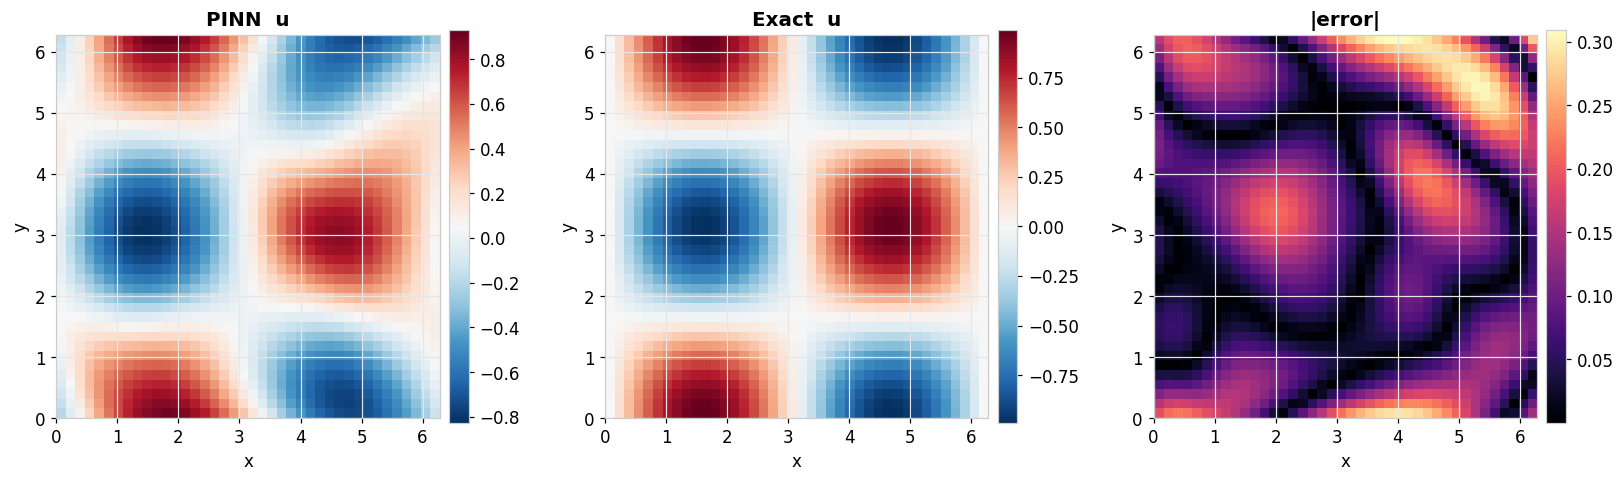

In [4]:
from pinnlab.utils.metrics import compute_error_metrics
U_true = tgv_u(T, X, Y, cfg.nu); V_true = tgv_v(T, X, Y, cfg.nu)

mu = compute_error_metrics(U, U_true)
rel_l2 = np.linalg.norm(U - U_true) / np.linalg.norm(U_true)     # global relative L2 norm
print(f"u-velocity   relative L2 = {rel_l2:.3e},  R² = {mu.r2_score:.4f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for a, data, title in [(ax[0], U, "PINN  u"),
                       (ax[1], U_true, "Exact  u"),
                       (ax[2], np.abs(U-U_true), "|error|")]:
    im = a.imshow(data, extent=[cfg.xmin, cfg.xmax, cfg.ymin, cfg.ymax],
                  origin="lower", cmap="RdBu_r" if "error" not in title else "magma")
    a.set(title=title, xlabel="x", ylabel="y", aspect="equal"); fig.colorbar(im, ax=a, pad=0.02)
plt.tight_layout(); plt.show()

<div style="background:#eaf2ff;border-left:5px solid #1a73e8;border-radius:8px;
            padding:14px 18px;margin:6px 0;font-family:'Segoe UI',sans-serif;font-size:14px;line-height:1.6;">
  <b>💡 Note.</b> On a CPU with a short training budget the PINN already recovers the vortex <i>structure</i>. Longer training, more collocation points, and the distributed trainer (see <a href='../advanced/02_distributed_training.ipynb'>advanced/02</a>) push the error down further.
</div>

<a id="takeaways"></a>

## 7 · Takeaways

- A single network with **multiple outputs** solves a coupled PDE system — velocity *and* pressure.
- Incompressibility is enforced as just another residual term in the loss.
- The Taylor–Green vortex is an invaluable **exact benchmark** for 2-D incompressible flow.
- Fluid PINNs are compute-hungry; this is where distributed training and adaptive sampling earn
  their keep.

### 📚 References

1. Taylor, G. I., & Green, A. E. (1937). *Mechanism of the production of small eddies from large ones*. Proc. R. Soc. Lond. A, 158(895), 499–521.
2. Raissi, M., Perdikaris, P., & Karniadakis, G. E. (2019). *Physics-informed neural networks*. J. Comput. Phys., 378, 686–707.

<div style="background:#0d1117;border-radius:12px;padding:22px 26px;color:#c9d1d9;
            font-family:'Segoe UI',sans-serif;font-size:13px;line-height:1.6;">
  <b style="color:#fff;font-size:15px;">Thanks for reading! 🙌</b><br>
  This notebook is part of the <code>pinnlab</code> example gallery. Explore the companion notebooks in
  <code>notebooks/basic</code>, <code>notebooks/advanced</code>, and <code>notebooks/benchmarks</code>
  for more physics-informed deep-learning recipes.
</div>